# Import libraries

In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path

import duckdb
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from matplotlib import rcParams
rcParams["text.usetex"] = True

import osbad.config as bconf
import osbad.modval as modval

# Import dataset

## Available cell_index

In [2]:
# Path to database directory
# "tohoku_benchmark_dataset.db" inside the database folder
DB_DIR = bconf.DB_DIR

db_filepath = DB_DIR.joinpath("tohoku_benchmark_dataset.db")

# Create a DuckDB connection
con = duckdb.connect(
    db_filepath,
    read_only=True)

# Load all training dataset from duckdb
df_duckdb = con.execute(
    "SELECT * FROM df_tohoku_dataset").fetchdf()

# Drop the additional index column
df_duckdb = df_duckdb.drop(
    columns="__index_level_0__",
    errors="ignore")

unique_cell_index_train = df_duckdb["cell_index"].unique()
print(unique_cell_index_train)

['cell_num_1' 'cell_num_2' 'cell_num_3' 'cell_num_4' 'cell_num_5'
 'cell_num_6' 'cell_num_7' 'cell_num_8' 'cell_num_9' 'cell_num_10']


## Define metrics filepath

In [3]:
TRAIN_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "01_train_dataset",
    "eval_metrics_hp_single_cell_tohoku.csv")

VALIDATE_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "02_validation_dataset",
    "eval_metrics_tohoku_train_multiple_cells.csv")

TEST_DATASET_METRICS_PATH = Path.cwd().joinpath(
    "03_test_dataset",
    "eval_metrics_tohoku_test_multiple_cells.csv")


# 01: Train on a single cell

* The models are trained and evaluated on the dataset from a single cell
* While all models have perfect accuracy, precision, recall, F1-score and MCC score from the training and evaluation based on a single cell, it also implies that the models could be overfitted.
* Therefore, it is important to consider how the models perform across the dataset from multiple cells.

## Plot evaluation metrics for a single cell

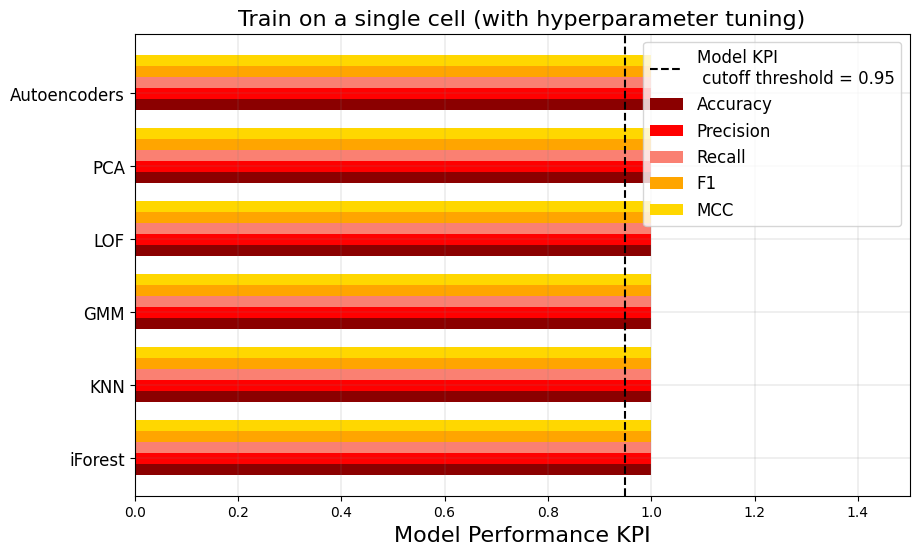

In [4]:
df_eval_metrics_train = pd.read_csv(TRAIN_DATASET_METRICS_PATH)

list_acc = df_eval_metrics_train["accuracy"].to_list()
list_precision = df_eval_metrics_train["precision"].to_list()
list_recall = df_eval_metrics_train["recall"].to_list()
list_f1 = df_eval_metrics_train["f1_score"].to_list()
list_mcc = df_eval_metrics_train["mcc_score"].to_list()

fig, ax = plt.subplots(figsize=(10,6))

bar_width = 0.15

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Train on a single cell (with hyperparameter tuning)",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_hp_single_cell.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 02: Validation across multiple cells

For the **hyperparameter tuning using the transfer learning method**:

* In the validation stage, the hyperparameter tuning is performed across 23 different cell experimental dataset.
* The best trial parameters are recorded for each model across all cells.
* The hyperparameters are subsequently averaged and transfer to the test dataset (another 23 cells).
* The corresponding model metrics are also recorded and then averaged to evaluate how each model performs across 23 different cell dataset during the validation stage.

## Drop duplicates in the training dataset

* Some metrics have been evaluated multiple times for the same ``ml_model`` and ``cell_index``
* ``df_eval_metrics_validate`` ensures that the combined ``ml_model`` and ``cell_index`` are unique

In [5]:
df_eval_metrics_validate = pd.read_csv(VALIDATE_DATASET_METRICS_PATH)

df_eval_metrics_validate = df_eval_metrics_validate.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")

## Calculate average metrics

* Calculate the mean and the standard deviation of ``accuracy``, ``precision``, ``recall``, ``f1_score`` and ``mcc_score`` across all evaluated cells in the training dataset.
* The standard deviation describes how consistently each model performs from cell to cell, which the mean alone does not convey.

In [6]:
df_compare_metrics = modval.summarize_eval_metrics(
    df_eval_metrics=df_eval_metrics_validate)

In [8]:
df_compare_metrics.to_excel("eval_metrics_train_transfer_learning.xlsx")
df_compare_metrics

,ml_model,n_cells,avg_accuracy,std_accuracy,avg_precision,std_precision,avg_recall,std_recall,avg_f1_score,std_f1_score,avg_mcc_score,std_mcc_score
0,iforest,4,1.000000,0.000000,1.00,0.000000,1.000000,0.000000,1.0000,0.000000,1.000000,0.000000
1,knn,4,0.998476,0.001924,1.00,0.000000,0.750000,0.319142,0.8250,0.236291,0.847957,0.200944
2,gmm,4,0.990721,0.009591,0.55,0.525991,0.500000,0.430331,0.5125,0.466146,0.514437,0.472176
3,lof,4,0.998476,0.001924,1.00,0.000000,0.750000,0.319142,0.8250,0.236291,0.847957,0.200944
4,pca,4,0.997394,0.003122,1.00,0.000000,0.666667,0.384900,0.7500,0.288675,0.787920,0.244889
5,autoencoder,4,0.997918,0.002937,1.00,0.000000,0.750000,0.319142,0.8250,0.236291,0.847795,0.201236


## Plot evaluation metrics for all cells

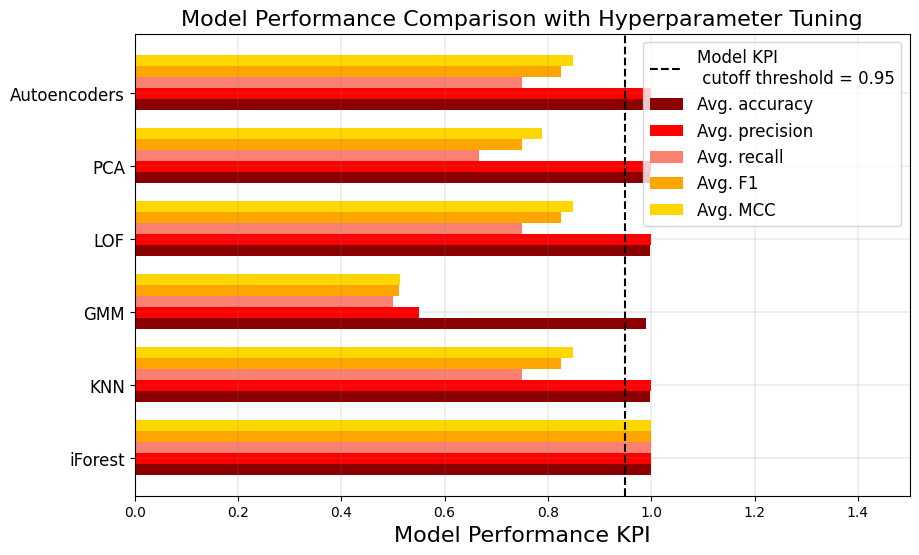

In [9]:
list_acc = df_compare_metrics["avg_accuracy"].to_list()
list_precision = df_compare_metrics["avg_precision"].to_list()
list_recall = df_compare_metrics["avg_recall"].to_list()
list_f1 = df_compare_metrics["avg_f1_score"].to_list()
list_mcc = df_compare_metrics["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Model Performance Comparison with Hyperparameter Tuning",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_with_hp_multiple_cells.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()

# 03: Test across multiple cells

* No more hyperparameter tuning is performed during the test phase.
* The models are simply tested on the remaining 23 cells to evaluate how each model with the frozen hyperparameters generalize to new dataset.

## Drop duplicates in the test dataset

In [10]:
df_eval_metrics_test = pd.read_csv(TEST_DATASET_METRICS_PATH)

df_eval_metrics_test = df_eval_metrics_test.drop_duplicates(
    subset=["ml_model", "cell_index"],
    keep="first")
df_eval_metrics_test

,ml_model,cell_index,accuracy,precision,recall,f1_score,mcc_score
0,iforest,cell_num_7,1.000000,1.000000,1.00,1.000000,1.000000
1,iforest,cell_num_8,1.000000,1.000000,1.00,1.000000,1.000000
2,iforest,cell_num_9,0.996198,1.000000,0.75,0.857143,0.864358
3,iforest,cell_num_10,1.000000,1.000000,1.00,1.000000,1.000000
4,knn,cell_num_7,0.685619,0.020833,1.00,0.040816,0.119330
5,knn,cell_num_8,0.994949,1.000000,0.50,0.666667,0.705310
6,knn,cell_num_9,0.969582,0.333333,1.00,0.500000,0.568364
7,knn,cell_num_10,0.945833,0.428571,0.90,0.580645,0.599569
8,gmm,cell_num_7,0.588629,0.016000,1.00,0.031496,0.096818
9,gmm,cell_num_8,1.000000,1.000000,1.00,1.000000,1.000000


In [11]:
unique_model_namelist = (
    df_eval_metrics_test["ml_model"].unique())
print(f"Unique model name list: {unique_model_namelist}")

Unique model name list: ['iforest' 'knn' 'gmm' 'lof' 'pca' 'autoencoder']


## Calculate average metrics

* Calculate the mean and the standard deviation of each metric across all evaluated cells in the test dataset.

In [12]:
df_compare_metrics_test = modval.summarize_eval_metrics(
    df_eval_metrics=df_eval_metrics_test)

df_compare_metrics_test.to_excel("eval_metrics_test_transfer_learning.xlsx")
df_compare_metrics_test

,ml_model,n_cells,avg_accuracy,std_accuracy,avg_precision,std_precision,avg_recall,std_recall,avg_f1_score,std_f1_score,avg_mcc_score,std_mcc_score
0,iforest,4,0.999049,0.001901,1.000000,0.000000,0.9375,0.125000,0.964286,0.071429,0.966090,0.067821
1,knn,4,0.898996,0.143658,0.445685,0.408526,0.8500,0.238048,0.447032,0.279230,0.498143,0.259253
2,gmm,4,0.777366,0.258562,0.522293,0.552102,0.9750,0.050000,0.541709,0.530885,0.564617,0.503433
3,lof,4,0.911954,0.159887,0.630000,0.470035,0.8500,0.238048,0.579979,0.384027,0.617331,0.353485
4,pca,4,0.998008,0.002305,1.000000,0.000000,0.9125,0.118145,0.951128,0.067390,0.952747,0.064072
5,autoencoder,4,0.998008,0.002305,1.000000,0.000000,0.9125,0.118145,0.951128,0.067390,0.952747,0.064072


## Plot evaluation metrics

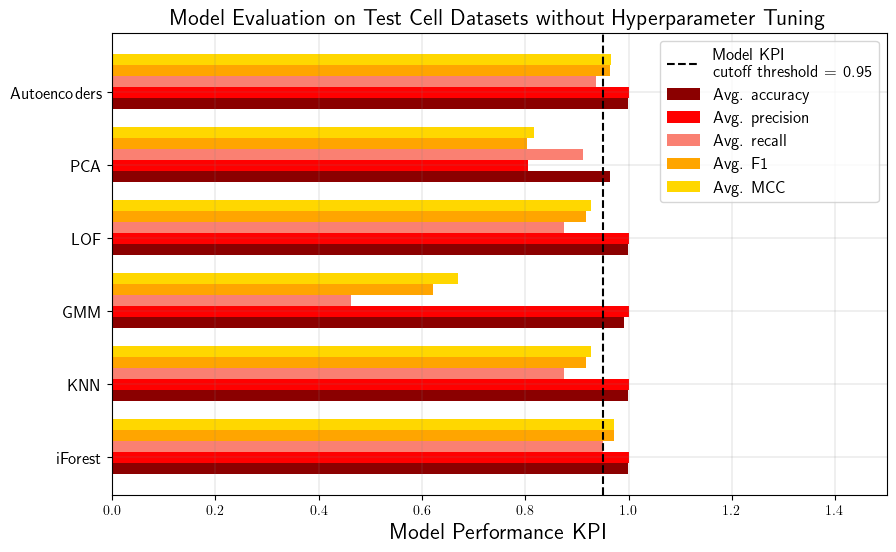

In [13]:
list_acc = df_compare_metrics_test["avg_accuracy"].to_list()
list_precision = df_compare_metrics_test["avg_precision"].to_list()
list_recall = df_compare_metrics_test["avg_recall"].to_list()
list_f1 = df_compare_metrics_test["avg_f1_score"].to_list()
list_mcc = df_compare_metrics_test["avg_mcc_score"].to_list()

bar_width = 0.15

fig, ax = plt.subplots(figsize=(10,6))

br1 = np.arange(len(list_acc))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]
br4 = [x + bar_width for x in br3]
br5 = [x + bar_width for x in br4]

ax.barh(br1, list_acc, color="darkred", height=bar_width, label="Avg. accuracy")
ax.barh(br2, list_precision, color="red", height=bar_width, label="Avg. precision")
ax.barh(br3, list_recall, color="salmon", height=bar_width, label="Avg. recall")
ax.barh(br4, list_f1, color="orange", height=bar_width, label="Avg. F1")
ax.barh(br5, list_mcc, color="gold", height=bar_width, label="Avg. MCC")
ax.grid(color="grey", linestyle="-", linewidth=0.25, alpha=0.7)
ax.set_xlim([0, 1.5])

ax.set_yticks(
    [r + bar_width for r in range(len(list_acc))], 
    ["iForest", "KNN", "GMM", "LOF", "PCA", "Autoencoders"],
    fontsize=12)

ax.set_xlabel("Model Performance KPI", fontsize=16)
ax.set_title(
    "Model Evaluation on Test Cell Datasets without Hyperparameter Tuning",
    fontsize=16)

ax.axvline(
    x=0.95,
    color="black",
    linestyle="--",
    label=f"Model KPI \n cutoff threshold = 0.95")

ax.legend(
    fontsize=12,
    loc="upper right")

fig_output_path =  "eval_metrics_test.png"

plt.savefig(
    fig_output_path,
    dpi=600,
    bbox_inches="tight")

plt.show()